In [90]:
# Install libraries using:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2>Data loading and Overview</h2>

In [126]:
# Loading Data.csv into dataframe
data_frame = pd.read_csv("Data.csv")

In [127]:
data_frame.shape

(21, 4)

<p style="font-size: 18px;font-weight: 500;">First 5 rows:</p>

In [128]:
data_frame.head(5)

,Country,Age,Salary,Purchased
0,India,34.0,92000.0,Yes
1,Sri lanka,22.0,25000.0,Yes
2,China,31.0,74000.0,Yes
3,Sri Lanka,29.0,NaN,Yes
4,China,NaN,98000.0,Yes


<p style="font-size: 18px;font-weight: 500;">Random 5 rows:</p>

In [129]:
data_frame.sample(5)

,Country,Age,Salary,Purchased
8,China,51.0,89000.0,Yes
11,China,25.0,30000.0,Yes
5,India,24.0,30000.0,No
0,India,34.0,92000.0,Yes
3,Sri Lanka,29.0,NaN,Yes


<p style="font-size: 18px;font-weight: 500;">Data types:</p>

In [130]:
data_frame.dtypes

Country       object
Age          float64
Salary       float64
Purchased     object
dtype: object

<p style="font-size: 18px;font-weight: 500;">General statistics:</p>

In [131]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    21 non-null     object 
 1   Age        19 non-null     float64
 2   Salary     19 non-null     float64
 3   Purchased  21 non-null     object 
dtypes: float64(2), object(2)
memory usage: 804.0+ bytes


In [132]:
data_frame.describe()

,Age,Salary
count,19.000000,19.000000
mean,35.947368,63605.263158
std,13.603405,39750.114936
min,21.000000,4500.000000
25%,27.000000,31500.000000
50%,31.000000,65000.000000
75%,43.000000,89000.000000
max,77.000000,178000.000000


<p style="font-size: 16px;">Shown by "data_frame.info()", the 'age' and 'salary' columns have only 19/21 non-null values. So, we'll inspect further:</p>

In [133]:
data_frame['Age']

0     34.0
1     22.0
2     31.0
3     29.0
4      NaN
5     24.0
6     28.0
7      NaN
8     51.0
9     44.0
10    21.0
11    25.0
12    33.0
13    42.0
14    51.0
15    44.0
16    26.0
17    31.0
18    29.0
19    77.0
20    41.0
Name: Age, dtype: float64

In [134]:
data_frame['Salary']

0      92000.0
1      25000.0
2      74000.0
3          NaN
4      98000.0
5      30000.0
6      40000.0
7      60000.0
8      89000.0
9      78000.0
10     20000.0
11     30000.0
12     45000.0
13     65000.0
14     89000.0
15    178000.0
16         NaN
17     33000.0
18      4500.0
19     67000.0
20     91000.0
Name: Salary, dtype: float64

<h2>Data Preprocessing</h2>

<p style="font-size: 18px;font-weight: 500;">Delete Duplicates</p>

In [135]:
data_frame = data_frame.drop_duplicates()

In [136]:
data_frame.shape

(20, 4)

<p style="font-size: 18px;font-weight: 500;">Handle missing values</p>

<p style="font-size: 14px;">We already know it's columns 'age' and 'salary' with missing values. Next, we need to check if their respective distributions are standard or skewed.</p>

In [137]:
data_frame.Age.describe().T

count    18.000000
mean     35.111111
std      13.485892
min      21.000000
25%      26.500000
50%      31.000000
75%      41.750000
max      77.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

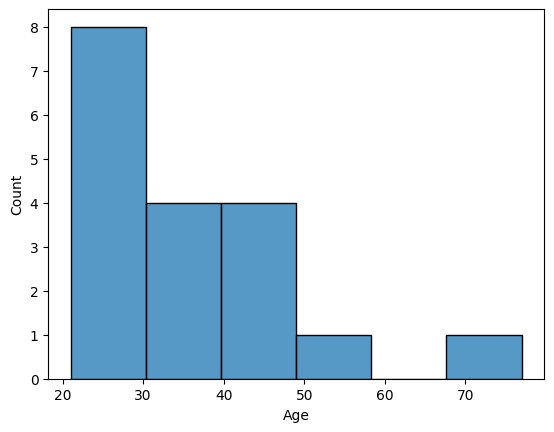

In [138]:
sns.histplot(data_frame['Age'])

In [139]:
data_frame.Salary.describe().T

count        18.000000
mean      62194.444444
std       40410.081331
min        4500.000000
25%       30750.000000
50%       62500.000000
75%       86250.000000
max      178000.000000
Name: Salary, dtype: float64

<Axes: xlabel='Salary', ylabel='Count'>

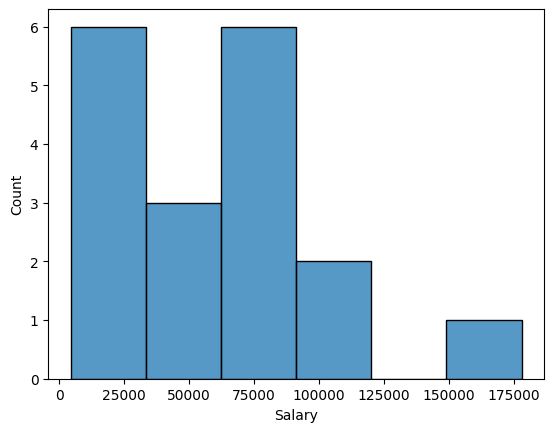

In [140]:
sns.histplot(data_frame['Salary'])

<p style="font-size: 14px;">Since our dataset is small, neither distribution is standard. So, we'll use the median for each to replace missing values.</p>

In [107]:
data_frame.loc[data_frame.Age.isnull(), 'Age'] = data_frame.Age.median()

In [108]:
data_frame.loc[data_frame.Salary.isnull(), 'Salary'] = data_frame.Salary.median()

<p style="font-size: 14px;">Now, let's check the new statistics of each column, and make sure there aren't still any missing values.</p>

In [109]:
data_frame.Age.describe().T

count    20.000000
mean     34.700000
std      12.818983
min      21.000000
25%      27.500000
50%      31.000000
75%      41.250000
max      77.000000
Name: Age, dtype: float64

In [110]:
data_frame['Age'].isnull().sum()

0

In [111]:
data_frame.Salary.describe().T

count        20.000000
mean      62225.000000
std       38224.225922
min        4500.000000
25%       32250.000000
50%       62500.000000
75%       80750.000000
max      178000.000000
Name: Salary, dtype: float64

In [112]:
data_frame['Salary'].isnull().sum()

0

<p style="font-size: 16px;">Double checking for missing values</p>

In [113]:
data_frame.isnull().sum()

Country      0
Age          0
Salary       0
Purchased    0
dtype: int64

<p style="font-size: 18px;font-weight: 500;">Handle outliers</p>

In [114]:
data_frame.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20.0,34.7,12.818983,21.0,27.5,31.0,41.25,77.0
Salary,20.0,62225.0,38224.225922,4500.0,32250.0,62500.0,80750.00,178000.0


<p style="font-size: 14px;">Since the dataset is small, we could likely assume the values 4500 and 178000 for 'salary' are outliers. However, we should still be thorough.</p>

In [115]:
# Getting values for q1, q3, and IQR of the Salary column 
quartile1 = data_frame.Salary.quantile(0.25)
print("Q1: ", quartile1)
quartile3 = data_frame.Salary.quantile(0.75)
print("Q3: ", quartile3)
IQR = quartile3 - quartile1
print("IQR: ", IQR)

print(data_frame.Salary)

Q1:  32250.0
Q3:  80750.0
IQR:  48500.0
0      92000.0
1      25000.0
2      74000.0
3      62500.0
4      98000.0
5      30000.0
6      40000.0
7      60000.0
8      89000.0
9      78000.0
10     20000.0
11     30000.0
12     45000.0
13     65000.0
15    178000.0
16     62500.0
17     33000.0
18      4500.0
19     67000.0
20     91000.0
Name: Salary, dtype: float64


In [116]:
# Finding outliers in the data, based on values for Q1, Q3, and IQR
outliers = data_frame.Salary[(data_frame.Salary<(quartile1-1.5*IQR)) | (data_frame.Salary>(quartile3+1.5*IQR))]
print(str(outliers))

15    178000.0
Name: Salary, dtype: float64


In [118]:
# Replacing outlier value with median value for Salary
data_frame.loc[data_frame['Salary'] == 178000.0, ['Salary']] = data_frame.Salary.median()

<p style="font-size: 18px;font-weight: 500;">Handle inconsistent data</p>

In [120]:
data_frame.dtypes

Country       object
Age          float64
Salary       float64
Purchased     object
dtype: object

In [121]:
data_frame['Country'].value_counts()

Country
India        9
China        6
Sri Lanka    3
Sri lanka    2
Name: count, dtype: int64

In [122]:
# Replacing 'Sri lanka' values with 'Sri Lanka'
data_frame.loc[data_frame['Country'] == 'Sri lanka', ['Country']] = 'Sri Lanka'

In [123]:
data_frame['Country'].value_counts()

Country
India        9
China        6
Sri Lanka    5
Name: count, dtype: int64

In [124]:
data_frame['Purchased'].value_counts()

Purchased
Yes    13
No      7
Name: count, dtype: int64